# Zugriff auf ein relationales Datenmodell mit SQL und Python

## Entity Modell
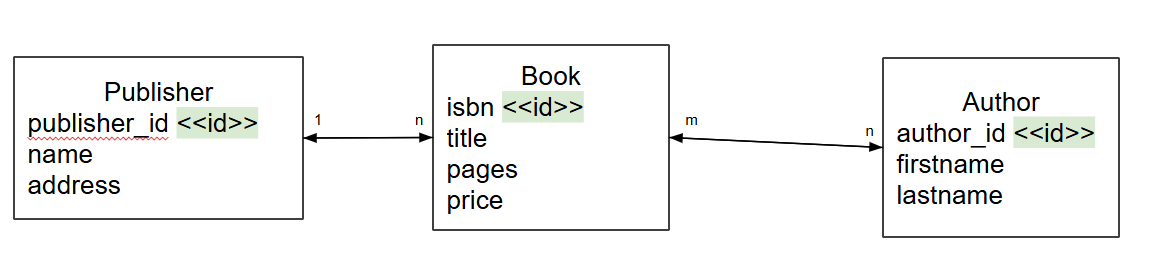

## Umsetzung

### Laden der Bibliotheken

In [10]:
import sqlite3
import random

### Erstellen von Connection und Cursor

In [11]:
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()
cursor.execute("PRAGMA foreign_keys = ON;")


### Erstellen der Tabellen

In [12]:
cursor.executescript("""
CREATE TABLE publisher (
    publisher_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    address TEXT
);

CREATE TABLE book (
    isbn TEXT PRIMARY KEY,
    title TEXT NOT NULL,
    pages INTEGER,
    price REAL,
    publisher_id INTEGER,
    FOREIGN KEY (publisher_id) REFERENCES publisher(publisher_id)
        ON DELETE SET NULL
        ON UPDATE CASCADE
);

CREATE TABLE author (
    author_id INTEGER PRIMARY KEY AUTOINCREMENT,
    firstname TEXT NOT NULL,
    lastname TEXT NOT NULL
);

CREATE TABLE book_author (
    book_isbn TEXT,
    author_id INTEGER,
    PRIMARY KEY (book_isbn, author_id),
    FOREIGN KEY (book_isbn) REFERENCES book(isbn)
        ON DELETE CASCADE
        ON UPDATE CASCADE,
    FOREIGN KEY (author_id) REFERENCES author(author_id)
        ON DELETE CASCADE
        ON UPDATE CASCADE
);
""")


### Testdaten hinzufügen

In [13]:
publishers = [
    ("Springer Verlag", "Heidelberg, Germany"),
    ("O'Reilly Media", "Sebastopol, USA"),
    ("Pearson Education", "London, UK")
]
cursor.executemany("INSERT INTO publisher (name, address) VALUES (?, ?)", publishers)

authors = [
    ("Alice", "Anderson"),
    ("Bob", "Brown"),
    ("Carol", "Clark"),
    ("David", "Davis"),
    ("Eve", "Evans"),
    ("Frank", "Foster"),
    ("Grace", "Green"),
    ("Hank", "Hill"),
    ("Ivy", "Irwin"),
    ("Jack", "Johnson")
]
cursor.executemany("INSERT INTO author (firstname, lastname) VALUES (?, ?)", authors)

for i in range(50):
    isbn = f"978-0-00-{1000000 + i}"
    title = f"Book Title {i+1}"
    pages = random.randint(100, 1000)
    price = round(random.uniform(10, 100), 2)
    publisher_id = random.randint(1, 3)
    cursor.execute(
        "INSERT INTO book (isbn, title, pages, price, publisher_id) VALUES (?, ?, ?, ?, ?)",
        (isbn, title, pages, price, publisher_id)
    )
    author_ids = random.sample(range(1, 11), random.randint(1, 3))
    for author_id in author_ids:
        cursor.execute(
            "INSERT INTO book_author (book_isbn, author_id) VALUES (?, ?)",
            (isbn, author_id)
)


## Analysen

### Bücher nach Title

In [14]:
statement = "select * from book where title like '%1%'"
cursor.execute(statement)
for row in cursor.fetchall():
    print(row)


('978-0-00-1000000', 'Book Title 1', 103, 52.64, 1)
('978-0-00-1000009', 'Book Title 10', 984, 98.81, 3)
('978-0-00-1000010', 'Book Title 11', 526, 39.5, 1)
('978-0-00-1000011', 'Book Title 12', 229, 39.57, 1)
('978-0-00-1000012', 'Book Title 13', 344, 59.06, 2)
('978-0-00-1000013', 'Book Title 14', 258, 13.48, 3)
('978-0-00-1000014', 'Book Title 15', 388, 69.25, 3)
('978-0-00-1000015', 'Book Title 16', 964, 75.66, 2)
('978-0-00-1000016', 'Book Title 17', 362, 66.68, 2)
('978-0-00-1000017', 'Book Title 18', 668, 64.36, 3)
('978-0-00-1000018', 'Book Title 19', 201, 13.12, 1)
('978-0-00-1000020', 'Book Title 21', 860, 25.19, 1)
('978-0-00-1000030', 'Book Title 31', 482, 91.84, 2)
('978-0-00-1000040', 'Book Title 41', 809, 44.62, 3)


### Welche Bücher hat der Autor 'Clark' geschrieben?

In [15]:
statement = "select b.title from book b join book_author ba on b.isbn = ba.book_isbn join author a on ba.author_id = a.author_id where a.lastname='Clark'"
cursor.execute(statement)
for row in cursor.fetchall():
    print(row)


('Book Title 1',)
('Book Title 11',)
('Book Title 12',)
('Book Title 13',)
('Book Title 14',)
('Book Title 16',)
('Book Title 36',)
('Book Title 41',)
('Book Title 44',)
('Book Title 46',)
('Book Title 50',)


### Welche Autoren schreiben für den Springer Verlag

In [16]:
statement = "select DISTINCT a.lastname, a.firstname from author a join book_author ba on a.author_id = ba.author_id join book b on b.isbn = ba.book_isbn join publisher p on b.publisher_id = p.publisher_id where p.name='Springer Verlag'"
cursor.execute(statement)
for row in cursor.fetchall():
    print(row)


('Johnson', 'Jack')
('Clark', 'Carol')
('Evans', 'Eve')
('Irwin', 'Ivy')
('Brown', 'Bob')
('Green', 'Grace')
('Foster', 'Frank')
('Hill', 'Hank')
('Davis', 'David')
('Anderson', 'Alice')


## Schließen von Cursor und Connection

In [17]:
cursor.close()
conn.close()